# Autoencoder Anomaly Detection — Hyperparameter Comparison (Drop Singletons + Stratified Split)

This notebook mirrors `autoencoder_hyperparameter_comparison_split.ipynb` but drops polymer classes with only a single observation before splitting, then uses a **stratified 80/20 train/test split** of `all_spectra.csv`.

- **Train** — 80% of `all_spectra.csv` (after dropping singletons), stratified by polymer class. Each model is trained exclusively on this.
- **Test** — 20% of `all_spectra.csv` (stratified) + all 55 `ambient_spectra.csv` samples. Neither split was seen during training.
- **Threshold** — set at `THRESHOLD_PERCENTILE` of the **training** reconstruction errors.

**Combinations tested:**

| # | Architecture (encoder) | Latent Dim | Description |
|---|---|---|---|
| 1 | 535 → 256 → 128 | 16 | Shallow, very compressed |
| 2 | 535 → 256 → 128 | 32 | Shallow, moderate compression |
| 3 | 535 → 256 → 128 | 64 | Shallow, less compressed |
| 4 | 535 → 512 → 256 → 128 | 16 | Deep, very compressed |
| 5 | 535 → 512 → 256 → 128 | 32 | Deep, moderate compression |
| 6 | 535 → 512 → 256 → 128 | 64 | Deep, less compressed |

**Fixed across all runs:** `LEARNING_RATE=1e-3`, `EPOCHS=100`, `BATCH_SIZE=64`, `THRESHOLD_PERCENTILE=95`

## 1. Hyperparameter Grid

In [1]:
# ── Fixed training settings ───────────────────────────────────────────────────

LEARNING_RATE        = 1e-3
EPOCHS               = 100
BATCH_SIZE           = 64
THRESHOLD_PERCENTILE = 95
TEST_SIZE            = 0.20
RANDOM_STATE         = 42

# ── Hyperparameter combinations ───────────────────────────────────────────────

CONFIGS = [
    {'hidden_dims': [256, 128],      'latent_dim': 16},
    {'hidden_dims': [256, 128],      'latent_dim': 32},
    {'hidden_dims': [256, 128],      'latent_dim': 64},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 16},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 32},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 64},
]

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate:')
for i, c in enumerate(CONFIGS, 1):
    arch = ' → '.join(str(h) for h in c['hidden_dims'])
    print(f'  [{i}] hidden=[{arch}]  latent={c["latent_dim"]}')

6 configurations to evaluate:
  [1] hidden=[256 → 128]  latent=16
  [2] hidden=[256 → 128]  latent=32
  [3] hidden=[256 → 128]  latent=64
  [4] hidden=[512 → 256 → 128]  latent=16
  [5] hidden=[512 → 256 → 128]  latent=32
  [6] hidden=[512 → 256 → 128]  latent=64


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

np.random.seed(RANDOM_STATE)

Using device: cpu


## 3. Load Data and Split

Polymer classes with only a single observation are dropped first to enable stratified splitting. The remaining data is split 80/20:
- **Train set (80%)** — used to train each autoencoder; no labels used during training.
- **Test set (20% normal + all ambient)** — used for evaluation only; neither split was seen during fitting.

Stratification on `polymer` ensures each class is proportionally represented in both splits.

In [3]:
df_polymer = pd.read_csv('../data/all_spectra.csv',     index_col=False)
df_amb     = pd.read_csv('../data/ambient_spectra.csv', index_col=False)

label_col   = 'polymer'
wavelengths = [c for c in df_polymer.columns if c != label_col]

# Drop singleton classes to enable stratified splitting
df_polymer = df_polymer[df_polymer[label_col].map(df_polymer[label_col].value_counts()) > 1]

# Stratified 80/20 split on polymer class
df_train, df_polymer_test = train_test_split(
    df_polymer,
    test_size=TEST_SIZE,
    stratify=df_polymer[label_col],
    random_state=RANDOM_STATE
)

df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)

X_train       = df_train[wavelengths].values.astype(np.float32)
X_test_normal = df_polymer_test[wavelengths].values.astype(np.float32)
X_anomaly     = df_amb[wavelengths].values.astype(np.float32)

X_test = np.concatenate([X_test_normal, X_anomaly], axis=0)

# Test labels: 0 = normal, 1 = anomaly
y_test = np.concatenate([
    np.zeros(len(df_polymer_test)),
    np.ones(len(df_amb))
])

print('── Dataset Split ──────────────────────────────────────────')
print(f'  all_spectra (after dropping singletons) : {df_polymer.shape}')
print(f'  Training set (80%)                      : {X_train.shape}')
print(f'  Test normal  (20%)                      : {X_test_normal.shape}')
print(f'  Test anomaly (ambient)                  : {X_anomaly.shape}')
print(f'  Test set total                          : {X_test.shape}')
print('───────────────────────────────────────────────────────────')

── Dataset Split ──────────────────────────────────────────
  all_spectra (after dropping singletons) : (1213, 537)
  Training set (80%)                      : (970, 536)
  Test normal  (20%)                      : (243, 536)
  Test anomaly (ambient)                  : (55, 536)
  Test set total                          : (298, 536)
───────────────────────────────────────────────────────────


## 4. Define Autoencoder Architecture

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            encoder_layers.append(nn.ReLU())
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            decoder_layers.append(nn.ReLU())
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))


print('Autoencoder class defined.')

Autoencoder class defined.


## 5. Run All Configurations

For each configuration:
1. Train on `X_train` (80% split) using MSE loss — no labels used.
2. Compute reconstruction error for `X_train`, `X_test_normal`, and `X_anomaly`.
3. Set threshold at `THRESHOLD_PERCENTILE` of **training** scores.
4. Evaluate on the full test set (`X_test_normal` + `X_anomaly`).

In [5]:
X_tensor = torch.tensor(X_train, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

input_dim = X_train.shape[1]
criterion = nn.MSELoss()

results = []

for cfg_idx, cfg in enumerate(CONFIGS):
    hidden_dims = cfg['hidden_dims']
    latent_dim  = cfg['latent_dim']
    arch_str    = ' → '.join(str(h) for h in hidden_dims)
    label       = f'[{arch_str}] → {latent_dim}'

    print(f'\n── Config {cfg_idx + 1}/{len(CONFIGS)}: hidden=[{arch_str}]  latent={latent_dim} ──')

    torch.manual_seed(RANDOM_STATE)
    model     = Autoencoder(input_dim, hidden_dims, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training loop
    train_losses = []
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        epoch_loss /= len(X_train)
        train_losses.append(epoch_loss)
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch [{epoch + 1:3d}/{EPOCHS}]  Loss: {epoch_loss:.6f}')

    # Compute reconstruction errors
    model.eval()
    with torch.no_grad():
        recon_train  = model(torch.tensor(X_train,       dtype=torch.float32).to(device)).cpu().numpy()
        recon_normal = model(torch.tensor(X_test_normal, dtype=torch.float32).to(device)).cpu().numpy()
        recon_amb    = model(torch.tensor(X_anomaly,     dtype=torch.float32).to(device)).cpu().numpy()

    scores_train   = np.mean((X_train       - recon_train)  ** 2, axis=1)
    scores_normal  = np.mean((X_test_normal - recon_normal) ** 2, axis=1)
    scores_anomaly = np.mean((X_anomaly     - recon_amb)    ** 2, axis=1)

    # Threshold from training scores
    threshold = np.percentile(scores_train, THRESHOLD_PERCENTILE)

    # Evaluate on test set
    all_test_scores = np.concatenate([scores_normal, scores_anomaly])
    pred_labels     = (all_test_scores > threshold).astype(int)

    roc_auc     = roc_auc_score(y_test, all_test_scores)
    cm          = confusion_matrix(y_test, pred_labels)
    fpr, tpr, _ = roc_curve(y_test, all_test_scores)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'label':          label,
        'hidden_dims':    hidden_dims,
        'latent_dim':     latent_dim,
        'train_losses':   train_losses,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_test_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
        'f1':             f1,
    })

    print(f'  → AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}  Precision={precision:.2f}  F1={f1:.2f}')

print('\nAll configurations complete.')


── Config 1/6: hidden=[256 → 128]  latent=16 ──
  Epoch [ 25/100]  Loss: 0.676065
  Epoch [ 50/100]  Loss: 0.716794
  Epoch [ 75/100]  Loss: 0.494296
  Epoch [100/100]  Loss: 0.464341
  → AUC=0.518  TP=0  FN=55  FP=8  TN=235  Recall=0.00  Precision=0.00  F1=0.00

── Config 2/6: hidden=[256 → 128]  latent=32 ──
  Epoch [ 25/100]  Loss: 0.810445
  Epoch [ 50/100]  Loss: 0.670505
  Epoch [ 75/100]  Loss: 0.550891
  Epoch [100/100]  Loss: 0.537012
  → AUC=0.466  TP=0  FN=55  FP=10  TN=233  Recall=0.00  Precision=0.00  F1=0.00

── Config 3/6: hidden=[256 → 128]  latent=64 ──
  Epoch [ 25/100]  Loss: 0.885639
  Epoch [ 50/100]  Loss: 0.576301
  Epoch [ 75/100]  Loss: 0.618339
  Epoch [100/100]  Loss: 0.611519
  → AUC=0.390  TP=0  FN=55  FP=13  TN=230  Recall=0.00  Precision=0.00  F1=0.00

── Config 4/6: hidden=[512 → 256 → 128]  latent=16 ──
  Epoch [ 25/100]  Loss: 0.917851
  Epoch [ 50/100]  Loss: 0.575915
  Epoch [ 75/100]  Loss: 0.485782
  Epoch [100/100]  Loss: 0.939973
  → AUC=0.529  

## 6. Training Loss Curves

One loss curve per configuration. A well-converged model shows a smooth decrease that flattens by the final epochs.

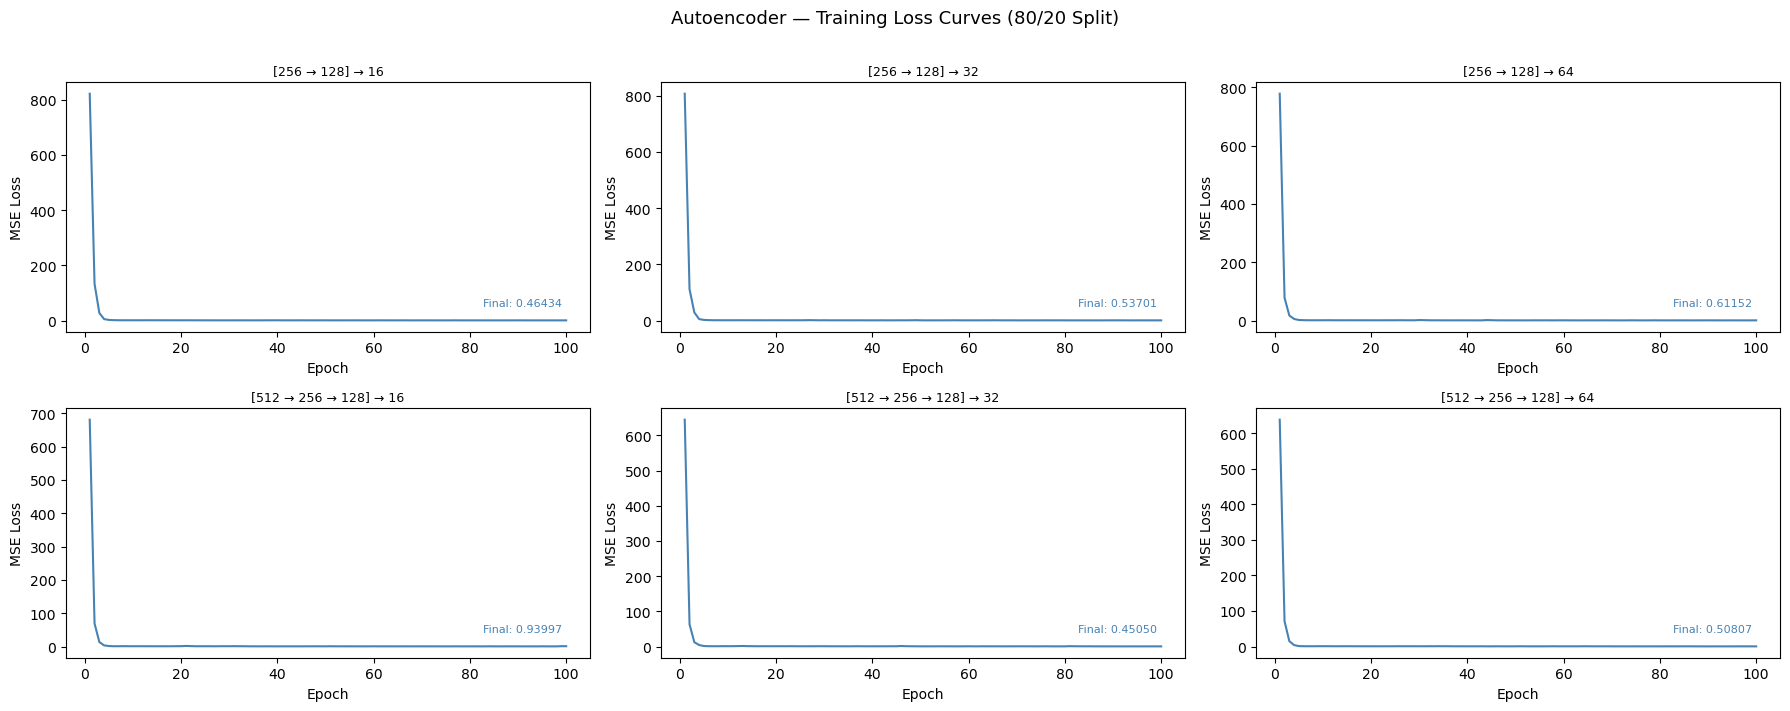

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(range(1, EPOCHS + 1), r['train_losses'], color='steelblue', lw=1.5)
    ax.set_title(r['label'], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    final_loss = r['train_losses'][-1]
    ax.annotate(f'Final: {final_loss:.5f}', xy=(EPOCHS, final_loss),
                xytext=(-60, 10), textcoords='offset points', fontsize=8, color='steelblue')

plt.suptitle('Autoencoder — Training Loss Curves (80/20 Split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_split_training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Anomaly Score Distributions

Blue = held-out normal test split (20%), orange = ambient anomalies, red dashed = decision threshold.
Well-separated distributions indicate the model distinguishes normal from anomalous spectra.

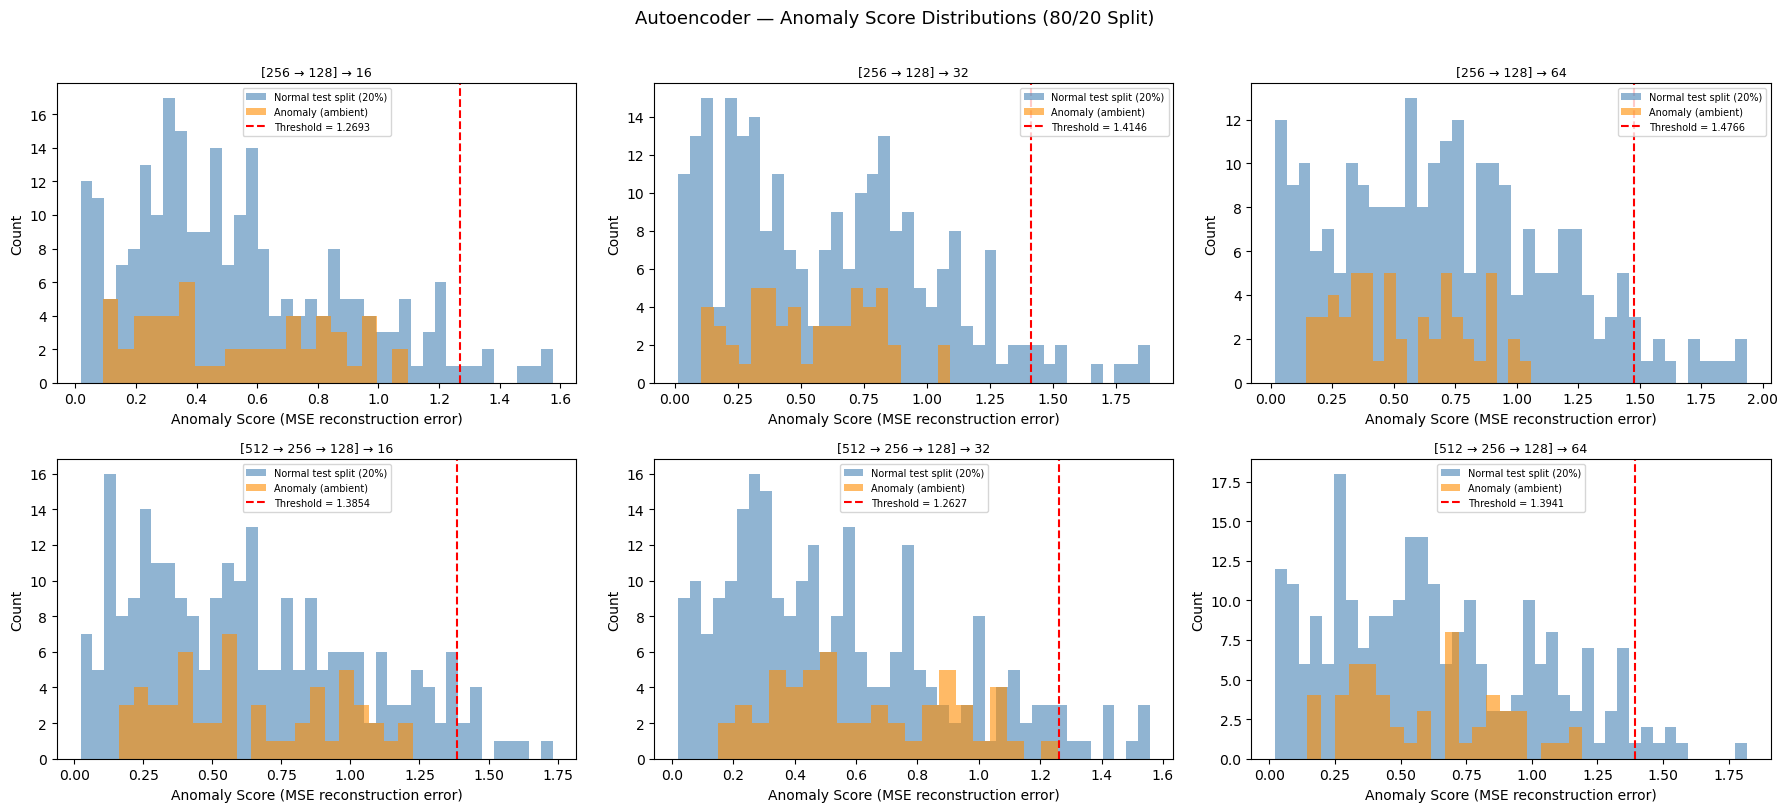

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    ax.hist(r['scores_normal'],  bins=40, alpha=0.6, color='steelblue',  label='Normal test split (20%)')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient)')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.4f}')
    ax.set_title(r['label'], fontsize=9)
    ax.set_xlabel('Anomaly Score (MSE reconstruction error)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Autoencoder — Anomaly Score Distributions (80/20 Split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_split_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

Evaluated on the test set (243 normal + 55 ambient = 298 samples total).
- **TP** — ambient anomalies correctly flagged (higher is better)
- **FN** — ambient anomalies missed (lower is better)
- **FP** — held-out normal samples incorrectly flagged

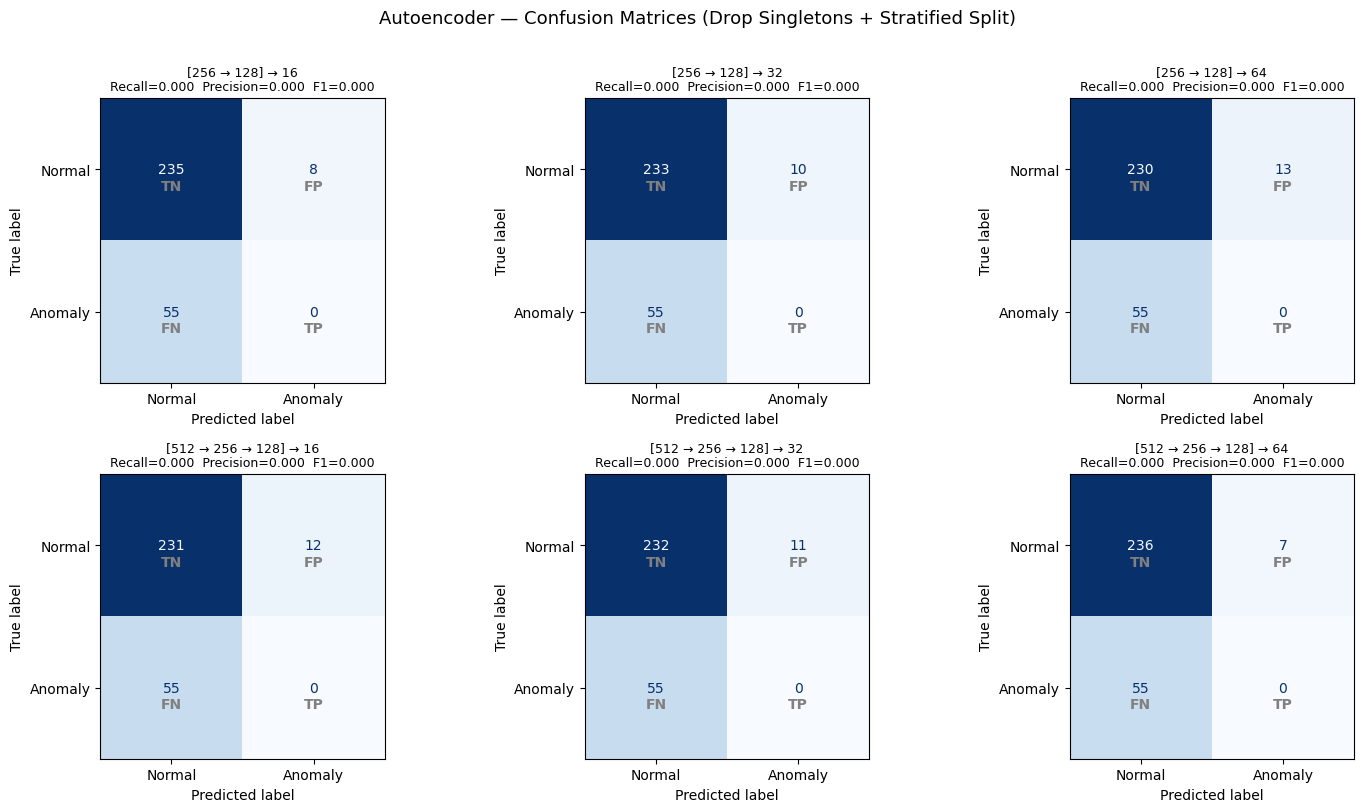

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')
    ax.set_title(
        f"{r['label']}\nRecall={r['recall']:.3f}  Precision={r['precision']:.3f}  F1={r['f1']:.3f}",
        fontsize=9
    )

plt.suptitle('Autoencoder — Confusion Matrices (Drop Singletons + Stratified Split)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_split_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC Curves

All 6 configurations on one chart. Curves closer to the top-left corner indicate better performance. The gray diagonal is the random baseline (AUC = 0.5).

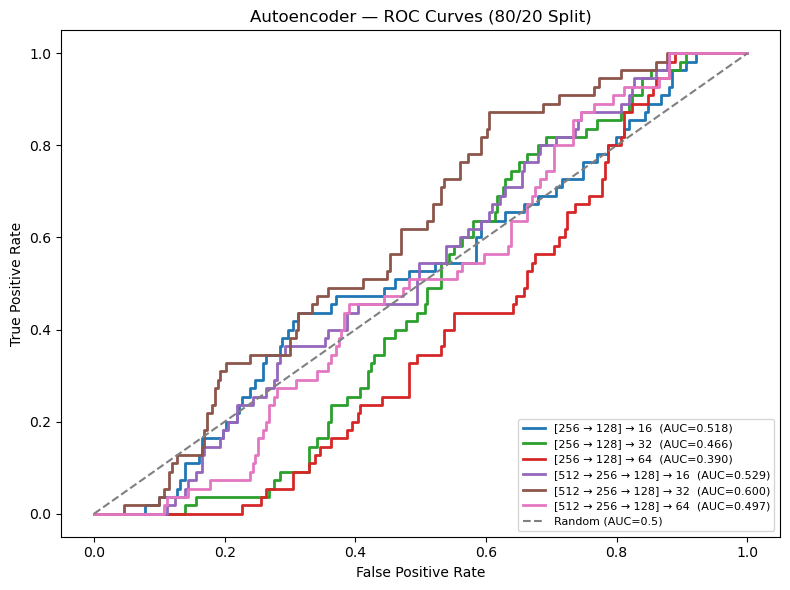

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Autoencoder — ROC Curves (80/20 Split)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/autoencoder_split_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table

All configurations ranked by ROC-AUC (descending).

- **AUC** — threshold-independent ranking ability
- **TP / FN** — anomalies caught / missed out of 55
- **FP / TN** — normal test samples misclassified / correctly classified out of 243
- **Recall** — TP / (TP + FN)
- **Precision** — TP / (TP + FP)

In [10]:
summary = pd.DataFrame([{
    'Configuration': r['label'],
    'Hidden Dims':   str(r['hidden_dims']),
    'Latent Dim':    r['latent_dim'],
    'Threshold':     round(r['threshold'], 6),
    'AUC':           round(r['roc_auc'], 3),
    'TP':            int(r['tp']),
    'FN':            int(r['fn']),
    'FP':            int(r['fp']),
    'TN':            int(r['tn']),
    'Recall':        round(r['recall'], 3),
    'Precision':     round(r['precision'], 3),
    'F1':            round(r['f1'], 3),
} for r in results])

summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)
display(summary)

,Configuration,Hidden Dims,Latent Dim,Threshold,AUC,TP,FN,FP,TN,Recall,Precision,F1
0,[512 → 256 → 128] → 32,"[512, 256, 128]",32,1.262746,0.600,0,55,11,232,0.0,0.0,0
1,[512 → 256 → 128] → 16,"[512, 256, 128]",16,1.385404,0.529,0,55,12,231,0.0,0.0,0
2,[256 → 128] → 16,"[256, 128]",16,1.269312,0.518,0,55,8,235,0.0,0.0,0
3,[512 → 256 → 128] → 64,"[512, 256, 128]",64,1.394106,0.497,0,55,7,236,0.0,0.0,0
4,[256 → 128] → 32,"[256, 128]",32,1.414624,0.466,0,55,10,233,0.0,0.0,0
5,[256 → 128] → 64,"[256, 128]",64,1.476583,0.390,0,55,13,230,0.0,0.0,0
